In [90]:
# --- Core Python ---
import os

# --- Numerical & Data Analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- Signal Processing ---
from scipy.signal import butter, filtfilt, resample, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Specialized Neuro Tools ---
import neurokit2 as nk

print("✅ Imports loaded")

# --- Pandas display settings (optional) ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)


✅ Imports loaded


In [91]:
# --- Respiration file paths (.h5) --- # Baseline recordings
resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}
resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
}
# --- BORIS annotation file paths (.csv) --- # Baseline recordings
boris_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_1_d1_2_20250623_111352.1.csv",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_2_sub1_1_20250623_133932.1_VT.csv",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_3_d2_4_20250623_151153.1.csv",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_4_sub2_3_20250623_143348.1_VT.csv",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_5_d3_6_20250623_160001.csv",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_6_sub3_5_20250623_174348.csv",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_7_d4_8_20250623_193718.csv",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_8_sub4_7_20250623_182649.1_VT.csv",
}

print(f"✅ Resp files: {len(resp_paths_cm)} trials")
print(f"✅ Resp files: {len(resp_paths_bl)} trials")
print(f"✅ BORIS files: {len(boris_paths_cm)} trials")

✅ Resp files: 8 trials
✅ Resp files: 8 trials
✅ BORIS files: 8 trials


In [92]:
# --- Respiration file paths (.h5) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}

# --- BORIS annotation file paths (.csv) ---
boris_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv",
}

print(f"✅ Resp files: {len(resp_paths)} trials")
print(f"✅ BORIS files: {len(boris_paths)} trials")

✅ Resp files: 23 trials
✅ BORIS files: 15 trials


In [166]:
boris_data_ri["RI2_3_5"].head(20)


,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
0,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,subject,142.098,facial sniffing,Not defined,STATE,4.067,4.600,0.533,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,122,138,NaN,NaN,NaN,NaN
1,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,social_agent,46.734,facial sniffing,Not defined,STATE,4.067,4.467,0.400,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,122,134,NaN,NaN,NaN,NaN
2,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,social_agent,46.734,body sniffing,Not defined,STATE,4.467,5.733,1.266,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,134,172,NaN,NaN,NaN,NaN
3,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,social_agent,46.734,facial sniffing,Not defined,STATE,12.033,12.267,0.234,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,361,368,NaN,NaN,NaN,NaN
4,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,subject,142.098,facial sniffing,Not defined,STATE,12.067,12.200,0.133,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,362,366,NaN,NaN,NaN,NaN
5,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,social_agent,46.734,fighting,Not defined,STATE,14.233,17.967,3.734,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,427,539,NaN,NaN,NaN,NaN
6,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,subject,142.098,Posturing,Not defined,STATE,18.100,20.533,2.433,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,543,616,NaN,NaN,NaN,NaN
7,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,social_agent,46.734,fighting,Not defined,STATE,20.467,22.633,2.166,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,614,679,NaN,NaN,NaN,NaN
8,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,subject,142.098,Posturing,Not defined,STATE,22.167,24.233,2.066,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,665,727,NaN,NaN,NaN,NaN
9,RI2_s3_5_nRB3,2025-06-27 12:59:24.834,NaN,Media file,player #1:E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_...,0.0,208.866,602.033,30.0,subject,142.098,facial sniffing,Not defined,STATE,32.900,33.133,0.233,E:/Aim1/AIM1/Day1_new/RI2_s3_5_p5_4_nRB3_20250...,987,994,NaN,NaN,NaN,NaN


In [93]:
# ======================================================
# 📦 Load Respiration Data (Cagemate, Resident–Intruder, Baseline)
# ======================================================

import os

# --- Helper function: Load all .h5 respiration files ---
def load_all_resp(resp_paths, label_prefix=""):
    """Load all respiration traces from provided path dictionary."""
    resp_data = {}
    for label, path in resp_paths.items():
        print(f"Processing {label_prefix}{label}...")
        signal, time, rate = load_clean_resp_signal(path)

        if signal is not None:
            resp_data[label] = {
                "signal": signal,
                "time": time,
                "sampling_rate": rate
            }
            print(f"✅ Loaded {label}: {len(signal)} samples, duration={time[-1]:.1f}s, fs={rate} Hz")
        else:
            print(f"❌ Skipped {label} (failed to load)")

    print(f"\n✅ Finished: {len(resp_data)} respiration traces loaded\n")
    return resp_data


# ======================================================
# 🧠 Patch RI files (metadata copy from ekg_metadata → resp_metadata)
# ======================================================

import h5py

def copy_ekg_to_resp_metadata(h5_path):
    """Copies sampling info from ekg_metadata → resp_metadata if missing."""
    try:
        with h5py.File(h5_path, "a") as f:
            if "ekg_metadata" not in f:
                return
            ekg_meta = f["ekg_metadata"].attrs
            if "resp_metadata" not in f:
                f.create_group("resp_metadata")
            resp_meta = f["resp_metadata"].attrs

            # Copy attributes only if they don't exist
            for key in ["sampling_frequency", "duration_sec"]:
                if key in ekg_meta and key not in resp_meta:
                    resp_meta[key] = ekg_meta[key]
                    print(f"✅ Copied {key}={ekg_meta[key]} to resp_metadata ({os.path.basename(h5_path)})")
    except Exception as e:
        print(f"⚠️ Could not patch {os.path.basename(h5_path)}: {e}")


In [94]:
# ======================================================
# 🛠️ Apply metadata fix to RI respiration files
# ======================================================
for path in resp_paths.values():
    copy_ekg_to_resp_metadata(path)

# ======================================================
# 🚀 Load all respiration sets
# ======================================================
resp_data_cm = load_all_resp(resp_paths_cm, "CM_")  # Cagemate
resp_data_ri = load_all_resp(resp_paths, "RI_")     # Resident–Intruder (Juvenile / CD1)
resp_data_bl = load_all_resp(resp_paths_bl, "BL_")  # Baseline

print(f"📊 Respiration loaded: CM={len(resp_data_cm)}, RI={len(resp_data_ri)}, BL={len(resp_data_bl)}")


Processing CM_CM_1_1_d1_2...
✅ Loaded CM_1_1_d1_2: 61262 samples, duration=612.6s, fs=100.0 Hz
Processing CM_CM_1_2_sub1_1...
✅ Loaded CM_1_2_sub1_1: 60566 samples, duration=605.6s, fs=100.0 Hz
Processing CM_CM_2_3_d2_4...
✅ Loaded CM_2_3_d2_4: 61143 samples, duration=611.4s, fs=100.0 Hz
Processing CM_CM_2_4_sub2_2...
✅ Loaded CM_2_4_sub2_2: 62196 samples, duration=622.0s, fs=100.0 Hz
Processing CM_CM_3_5_d3_6...
✅ Loaded CM_3_5_d3_6: 60594 samples, duration=605.9s, fs=100.0 Hz
Processing CM_CM_3_6_sub3_5...
✅ Loaded CM_3_6_sub3_5: 60426 samples, duration=604.2s, fs=100.0 Hz
Processing CM_CM_4_7_d4_8...
✅ Loaded CM_4_7_d4_8: 60319 samples, duration=603.2s, fs=100.0 Hz
Processing CM_CM_4_8_sub4_7...
✅ Loaded CM_4_8_sub4_7: 60508 samples, duration=605.1s, fs=100.0 Hz

✅ Finished: 8 respiration traces loaded

Processing RI_RI1_3_6...
✅ Loaded RI1_3_6: 60327 samples, duration=603.3s, fs=100.0 Hz
Processing RI_RI2_3_6...
✅ Loaded RI2_3_6: 61000 samples, duration=610.0s, fs=100.0 Hz
Processi

In [100]:
print("BORIS CM keys:")
print(sorted(list(boris_data_cm.keys())))

print("\nRespiration CM keys:")
print(sorted(list(resp_data_cm.keys())))


BORIS CM keys:
['CM_1_1_d1_2', 'CM_1_2_sub1_1', 'CM_2_3_d2_4', 'CM_2_4_sub2_3', 'CM_3_5_d3_6', 'CM_3_6_sub3_5', 'CM_4_7_d4_8', 'CM_4_8_sub4_7']

Respiration CM keys:
['CM_1_1_d1_2', 'CM_1_2_sub1_1', 'CM_2_3_d2_4', 'CM_2_4_sub2_2', 'CM_3_5_d3_6', 'CM_3_6_sub3_5', 'CM_4_7_d4_8', 'CM_4_8_sub4_7']


In [118]:
# ======================================================
# ✅ Final key normalization for Cagemate trials
# ======================================================

def fix_cm_key(k):
    """Standardize CM trial names so BORIS & Resp match."""
    # Unify prefix (some Resp files have 'CM_CM_')
    k = k.replace("CM_CM_", "CM_")
    # Fix typo: sub2_2 -> sub2_3
    k = k.replace("sub2_2", "sub2_3")
    return k

# Apply to both datasets
resp_data_cm_fixed  = {fix_cm_key(k): v for k, v in resp_data_cm.items()}
boris_data_cm_fixed = {fix_cm_key(k): v for k, v in boris_data_cm.items()}



In [119]:
# --- Re-run summaries ---
resp_summary_cm  = summarize_resp(resp_data_cm_fixed)
boris_summary_cm = summarize_boris(boris_data_cm_fixed, "Cagemate", rank_fix)

# --- Merge (outer keeps all valid trials) ---
merged_cm = pd.merge(boris_summary_cm, resp_summary_cm, on="Trial", how="outer")
print("✅ CM Trials now in merged_cm:")
print(sorted(merged_cm["Trial"].tolist()))


✅ CM Trials now in merged_cm:
['CM_1_1_d1_2', 'CM_1_2_sub1_1', 'CM_2_3_d2_4', 'CM_2_4_sub2_3', 'CM_3_5_d3_6', 'CM_3_6_sub3_5', 'CM_4_7_d4_8', 'CM_4_8_sub4_7']


In [131]:
# 🧹 Drop duplicate trial manually
merged_cm = merged_cm.drop_duplicates(subset="Trial", keep="first").reset_index(drop=True)

print(f"✅ Cleaned CM trials: {len(merged_cm)} total")
print(sorted(merged_cm['Trial'].tolist()))



✅ Cleaned CM trials: 8 total
['CM_1_1_d1_2', 'CM_1_2_sub1_1', 'CM_2_3_d2_4', 'CM_2_4_sub2_3', 'CM_3_5_d3_6', 'CM_3_6_sub3_5', 'CM_4_7_d4_8', 'CM_4_8_sub4_7']


In [132]:
merged_all = pd.concat([merged_cm, merged_ri], ignore_index=True)
print(f"✅ merged_all shape: {merged_all.shape}")


✅ merged_all shape: (23, 11)


In [133]:
print(merged_all)


            Trial Subject_ID    Condition  allogrooming  anogenital sniffing  body sniffing  chasing  facial sniffing  fighting  Resp_MeanRate  Posturing
0     CM_1_1_d1_2        1_1  Subordinate        12.800                4.868         10.661   26.366            5.367     31.43       6.916309        NaN
1   CM_1_2_sub1_1        1_2     Dominant         0.000                3.233          5.966    0.000            4.235      0.00       5.990258        NaN
2     CM_2_3_d2_4        2_3  Subordinate         0.000              557.667         16.904    0.000           16.865      0.00       7.407347        NaN
3   CM_2_4_sub2_3        2_4     Dominant         0.000                6.933          9.064    0.000           29.261      0.00       6.478013        NaN
4     CM_3_5_d3_6        3_5  Subordinate         0.000                3.932         20.135    0.000           20.799      0.00       6.449590        NaN
5   CM_3_6_sub3_5        3_6     Dominant           NaN                  NaN

In [136]:
# --- Keep trials with known social context ---
valid_conditions = ["Dominant", "Subordinate", "Juvenile", "CD1"]
df_multi = merged_all[merged_all["Condition"].isin(valid_conditions)].copy()

print(f"✅ Total labeled trials: {len(df_multi)}")
print(df_multi["Condition"].value_counts())


✅ Total labeled trials: 23
Condition
CD1            8
Juvenile       7
Subordinate    4
Dominant       4
Name: count, dtype: int64


In [137]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
import pandas as pd

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(df_multi["Condition"])

# Features
feature_cols = [
    "allogrooming", "anogenital sniffing", "body sniffing",
    "chasing", "facial sniffing", "fighting", "Resp_MeanRate"
]
X = df_multi[feature_cols].fillna(0)

# Model
model = make_pipeline(StandardScaler(),
                      LogisticRegression(max_iter=1000, multi_class="multinomial"))

scores = cross_val_score(model, X, y_enc, cv=5, scoring="accuracy")

print(f"✅ Mean 5-fold CV accuracy: {scores.mean():.2f} ± {scores.std():.2f}")
print("\nLabel mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx}: {cls}")


✅ Mean 5-fold CV accuracy: 0.61 ± 0.08

Label mapping:
  0: CD1
  1: Dominant
  2: Juvenile
  3: Subordinate


In [138]:
model.fit(X, y_enc)
coefs = model.named_steps["logisticregression"].coef_
coef_df = pd.DataFrame(coefs.T, index=feature_cols, columns=le.classes_)
display(coef_df.round(3))


,CD1,Dominant,Juvenile,Subordinate
allogrooming,-0.232,-0.077,-0.228,0.537
anogenital sniffing,-0.213,-0.119,-0.215,0.548
body sniffing,-0.117,-0.380,0.578,-0.081
chasing,0.037,-0.064,-0.093,0.119
facial sniffing,-0.896,0.761,-0.100,0.235
fighting,-0.081,-0.033,-0.035,0.149
Resp_MeanRate,-0.541,-1.072,1.506,0.107


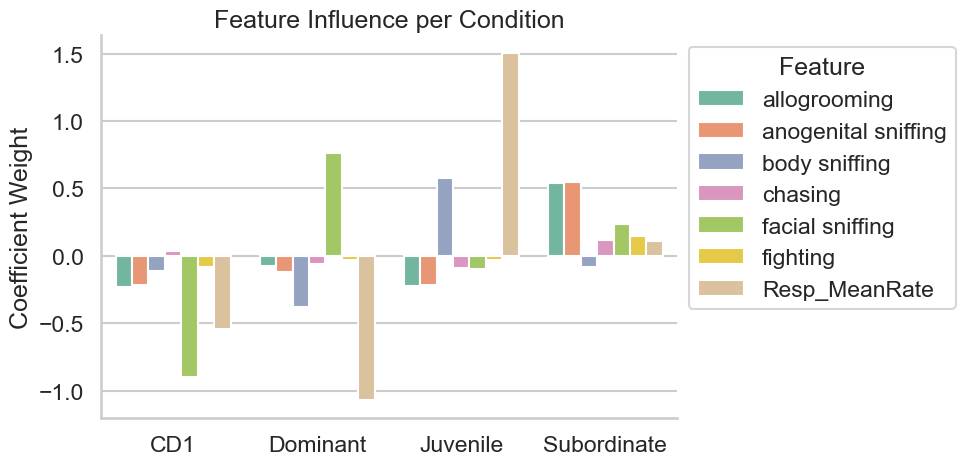

In [161]:
import seaborn as sns, matplotlib.pyplot as plt

coef_long = coef_df.reset_index().melt(id_vars="index", var_name="Condition", value_name="Weight")
plt.figure(figsize=(10,5))
sns.barplot(data=coef_long, x="Condition", y="Weight", hue="index")
plt.title("Feature Influence per Condition")
plt.ylabel("Coefficient Weight")
plt.xlabel("")
plt.legend(title="Feature", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


In [140]:
# --- Extract Rank (Dominant/Subordinate) ---
df_rank = merged_all[merged_all["Condition"].isin(["Dominant", "Subordinate"])].copy()

# --- Extract Valence (Juvenile/CD1) ---
df_valence = merged_all[merged_all["Condition"].isin(["Juvenile", "CD1"])].copy()


In [141]:
feature_cols = [
    "allogrooming", "anogenital sniffing", "body sniffing",
    "chasing", "facial sniffing", "fighting", "Resp_MeanRate"
]


In [142]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
import pandas as pd

def fit_axis_model(df, label_name):
    X = df[feature_cols].fillna(0)
    y = df["Condition"]
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    scores = cross_val_score(model, X, y_enc, cv=5, scoring="accuracy")
    model.fit(X, y_enc)

    coefs = model.named_steps["logisticregression"].coef_[0]
    coef_df = pd.DataFrame({
        "Feature": feature_cols,
        "Weight": coefs
    }).set_index("Feature")

    print(f"✅ {label_name} classifier: {le.classes_.tolist()} | Mean acc={scores.mean():.2f} ± {scores.std():.2f}")
    return coef_df


In [144]:
# Check how many trials per condition
merged_all["Condition"].value_counts()


Condition
CD1            8
Juvenile       7
Subordinate    4
Dominant       4
Name: count, dtype: int64

In [157]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import LeaveOneGroupOut
import warnings

# Choose the features you want the model to consider.
# We'll safely intersect these with what's actually in merged_all.
CANDIDATE_FEATURES = [
    "Resp_MeanRate", "Resp_IBI_std", "Resp_IBI_cv",
    "Resp_Amp_mean", "Resp_Amp_cv", "Resp_Power_total", "Resp_Power_ratioHL",
    "Session_Rate_Hz",
    "allogrooming", "anogenital sniffing", "body sniffing",
    "chasing", "facial sniffing", "fighting", "Posturing"
]


def pick_features(df, candidates):
    """Return (feature_cols, X) after intersecting with available columns and filling NaNs."""
    cols = [c for c in candidates if c in df.columns]
    X = df[cols].astype(float).fillna(0.0)
    return cols, X

def l1_logreg_pipeline():
    """Binary L1 logistic (liblinear supports L1 for binary)."""
    return make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        LogisticRegression(
            penalty="l1", solver="liblinear", max_iter=2000, class_weight=None
        )
    )

def best_n_splits(y_enc, max_cap=5, floor=2):
    """
    Pick a safe #folds for StratifiedKFold given class counts.
    Ensures every fold has at least 1 sample per class.
    """
    counts = np.bincount(y_enc)
    min_per_class = counts.min()
    return int(max(floor, min(min_per_class, max_cap)))

def nonzero_coefs(pipeline, feature_cols):
    """Return a sorted Series of non-zero L1 coefficients (positive → class 1, negative → class 0)."""
    lr = pipeline.named_steps["logisticregression"]
    coefs = pd.Series(lr.coef_.ravel(), index=feature_cols)
    nz = coefs[coefs != 0].sort_values(key=lambda s: s.abs(), ascending=False)
    return nz


In [158]:
# -------------------------
# RANK DATA (Dom vs Sub)
# -------------------------
df_rank = merged_all[merged_all["Condition"].isin(["Dominant", "Subordinate"])].copy()

# Label encode: Dominant=1, Subordinate=0
df_rank["y"] = (df_rank["Condition"] == "Dominant").astype(int)

# Features
rank_features, X_rank = pick_features(df_rank, CANDIDATE_FEATURES)
y_rank = df_rank["y"].values
groups_rank = df_rank["Subject_ID"].astype(str).values  # for across-subject CV

print(f"Rank: n={len(df_rank)}, subjects={df_rank['Subject_ID'].nunique()}, features={rank_features}")

# ---------- Within-subject CV ----------
cv_ws = StratifiedKFold(
    n_splits=best_n_splits(y_rank, max_cap=5, floor=2),
    shuffle=True, random_state=42
)
rank_model = l1_logreg_pipeline()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ws_scores = cross_val_score(rank_model, X_rank, y_rank, cv=cv_ws, scoring="accuracy")

print(f"[Rank] Within-subject CV accuracy: {ws_scores.mean():.2f} ± {ws_scores.std():.2f} (n_splits={cv_ws.n_splits})")

# ---------- Across-subject CV (leave-one-subject-out) ----------
logo = LeaveOneGroupOut()
accs = []
for train_idx, test_idx in logo.split(X_rank, y_rank, groups=groups_rank):
    if len(np.unique(y_rank[train_idx])) < 2 or len(np.unique(y_rank[test_idx])) < 2:
        # if a fold has only one class, skip (too few samples for that subject)
        continue
    m = l1_logreg_pipeline()
    m.fit(X_rank.iloc[train_idx], y_rank[train_idx])
    yhat = m.predict(X_rank.iloc[test_idx])
    accs.append(accuracy_score(y_rank[test_idx], yhat))

if accs:
    print(f"[Rank] Across-subject (LOSO) accuracy: {np.mean(accs):.2f} ± {np.std(accs):.2f}  (folds={len(accs)})")
else:
    print("[Rank] Across-subject (LOSO): not enough data to compute.")

# ---------- Fit final model on all rank data and show L1-selected features ----------
rank_final = l1_logreg_pipeline().fit(X_rank, y_rank)
nz_rank = nonzero_coefs(rank_final, rank_features)
print("\n[Rank] Non-zero L1 coefficients (→ Dominant if positive):")
display(nz_rank)


Rank: n=8, subjects=8, features=['Resp_IBI_std', 'Resp_IBI_cv', 'Resp_Amp_mean', 'Resp_Amp_cv', 'Resp_Power_total', 'Resp_Power_ratioHL', 'allogrooming', 'anogenital sniffing', 'body sniffing', 'chasing', 'facial sniffing', 'fighting', 'Posturing']
[Rank] Within-subject CV accuracy: 0.62 ± 0.41 (n_splits=4)
[Rank] Across-subject (LOSO): not enough data to compute.

[Rank] Non-zero L1 coefficients (→ Dominant if positive):


Resp_Power_ratioHL    -0.623222
body sniffing         -0.561216
anogenital sniffing   -0.114193
Resp_Power_total      -0.080323
dtype: float64

In [159]:
resp_data[trial] = {"signal": sig, "time": t, "sampling_rate": fs}


In [160]:
import numpy as np
from scipy.signal import find_peaks, welch

def compute_resp_features(signal, time, fs=100):
    """Extract rich respiration features per trial."""
    # Mask any NaNs
    sig = np.nan_to_num(signal)
    
    # --- Basic rate features ---
    dur = time[-1] - time[0]
    peaks, _ = find_peaks(sig, distance=fs * 0.0833)  # ≥12 Hz refractory
    ibi = np.diff(time[peaks]) if len(peaks) > 1 else np.array([np.nan])
    rate = len(peaks) / dur if dur > 0 else np.nan
    
    # --- Variability metrics ---
    ibi_std = np.nanstd(ibi)
    ibi_cv = ibi_std / np.nanmean(ibi) if np.nanmean(ibi) > 0 else np.nan
    
    # --- Amplitude metrics ---
    amp = sig[peaks] if len(peaks) > 0 else np.array([np.nan])
    amp_mean = np.nanmean(amp)
    amp_std = np.nanstd(amp)
    amp_cv = amp_std / amp_mean if amp_mean > 0 else np.nan

    # --- Spectral power metrics (0–10 Hz window) ---
    f, Pxx = welch(sig, fs=fs, nperseg=fs*2)
    band_mask = f < 10
    total_power = np.trapz(Pxx[band_mask], f[band_mask])
    low_band = np.trapz(Pxx[(f>=1) & (f<4)], f[(f>=1) & (f<4)])  # 1–4 Hz
    high_band = np.trapz(Pxx[(f>=4) & (f<8)], f[(f>=4) & (f<8)])  # 4–8 Hz
    ratio_highlow = high_band / low_band if low_band > 0 else np.nan

    return {
        "Resp_MeanRate": rate,
        "Resp_IBI_std": ibi_std,
        "Resp_IBI_cv": ibi_cv,
        "Resp_Amp_mean": amp_mean,
        "Resp_Amp_cv": amp_cv,
        "Resp_Power_total": total_power,
        "Resp_Power_ratioHL": ratio_highlow
    }


| Feature            | Reflects                       | Relevance to Rank/Valence                                   |
| ------------------ | ------------------------------ | ----------------------------------------------------------- |
| Resp_MeanRate      | Overall arousal/sniffing tempo | Higher in positive (appetitive) conditions → active investigation and approach; lower in negative (aversive) conditions → freezing, vigilance, or inhibition.    |
| Resp_IBI_std / CV  | Temporal irregularity          | Instability during stress or approach/avoidance transitions |
| Resp_Amp_mean / CV | Breath depth and variability   | Deep steady breaths in calm/social dominance                |
| Resp_Power_total   | Global rhythmicity strength    | Stronger oscillatory drive during engagement                |
| Resp_Power_ratioHL | Relative sniffing mode         | Fast (4–8 Hz) = exploration/stress; slow (1–4 Hz) = calm    |


In [154]:
resp_features_list = []

for trial, rec in resp_data.items():
    feats = compute_resp_features(rec["signal"], rec["time"], rec["sampling_rate"])
    feats["Trial"] = trial
    resp_features_list.append(feats)

resp_feat_df = pd.DataFrame(resp_features_list)
print(resp_feat_df.head())


   Resp_MeanRate  Resp_IBI_std  Resp_IBI_cv  Resp_Amp_mean  Resp_Amp_cv  Resp_Power_total  Resp_Power_ratioHL          Trial
0       6.916309      0.044011     0.304448     796.040990     0.602255     382063.320567           12.331834    CM_1_1_d1_2
1       5.990258      0.083327     0.499261     866.685189     0.739009     399643.803676            1.293628  CM_1_2_sub1_1
2       7.407347      0.060538     0.448514    1065.428505     0.628143     395030.523042            2.602790    CM_2_3_d2_4
3       6.478013      0.069305     0.448919    1018.314545     0.538782     378941.750153            2.741833  CM_2_4_sub2_2
4       6.449590      0.077733     0.501269    1244.473448     0.574782     597964.465198            3.641311    CM_3_5_d3_6


In [155]:
merged_all = merged_all.merge(resp_feat_df, on="Trial", how="left")
